 01 — SALICON PyTorch Data Pipeline

This notebook validates the reusable PyTorch data pipeline used by the
Efficient Visual Saliency Prediction project.

The dataset preparation stage has already been completed in
`00_dataset_preparation.ipynb`.

That notebook already:

- located and audited the SALICON dataset;
- matched RGB images with their saliency maps;
- created the dataset manifest;
- created the fixed train, validation and internal test splits;
- saved the split manifests and metadata.

This notebook does not download SALICON and does not regenerate the splits.

Its objectives are to:

1. connect the GitHub source code with the SALICON files stored in Google Drive;
2. inspect the existing manifest structure;
3. construct PyTorch Dataset objects;
4. construct train, validation and test DataLoaders;
5. verify tensor shapes and saliency-map normalization;
6. visually verify that RGB images and targets remain spatially aligned.

## 1. Position in the project workflow

The project compares three CNN-based saliency models:

1. **Light-S** uses a lightweight MobileNetV2 encoder and predicts saliency
   from only its deepest feature representation.
2. **Light-M** uses the same MobileNetV2 encoder but combines features
   extracted at different depths.
3. **Heavy-M** uses a larger ResNet-18 encoder with the same multi-scale
   decoder used by Light-M.

All three models must use exactly the same samples, preprocessing, target
normalization and DataLoader logic.

For this reason, the data pipeline is implemented once in `src/data.py` and
will be reused by every model.

## 2. Project storage design

The project uses three different environments:

- **GitHub repository:** source code, notebooks and fixed split manifests;
- **Google Drive:** SALICON data, checkpoints, logs, figures and metrics;
- **Google Colab:** temporary execution environment and GPU access.

Files stored only under `/content/` disappear when the Colab runtime is reset.
Important generated artifacts must therefore be saved to Google Drive, while
source code must be committed to GitHub.

In [43]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
from pathlib import Path

REPO_ROOT = Path("/content/efficient-saliency-prediction")

if not REPO_ROOT.exists():
    %cd /content
    !git clone https://github.com/RicoDalB/efficient-saliency-prediction.git
else:
    %cd /content/efficient-saliency-prediction
    !git pull --ff-only

%cd /content/efficient-saliency-prediction

/content/efficient-saliency-prediction
Already up to date.
/content/efficient-saliency-prediction


In [59]:
!find /content/efficient-saliency-prediction -maxdepth 2 -type f | sort

/content/efficient-saliency-prediction/documentation/data_audit.json
/content/efficient-saliency-prediction/documentation/github_workflow.md
/content/efficient-saliency-prediction/.git/config
/content/efficient-saliency-prediction/.git/description
/content/efficient-saliency-prediction/.git/FETCH_HEAD
/content/efficient-saliency-prediction/.git/HEAD
/content/efficient-saliency-prediction/.gitignore
/content/efficient-saliency-prediction/.git/index
/content/efficient-saliency-prediction/.git/ORIG_HEAD
/content/efficient-saliency-prediction/.git/packed-refs
/content/efficient-saliency-prediction/notebooks/00_dataset_preparation.ipynb
/content/efficient-saliency-prediction/README.md
/content/efficient-saliency-prediction/requirements.txt
/content/efficient-saliency-prediction/splits/dataset_manifest.csv
/content/efficient-saliency-prediction/splits/split_metadata.json
/content/efficient-saliency-prediction/splits/test_manifest.csv
/content/efficient-saliency-prediction/splits/test.txt
/co

In [46]:
from pathlib import Path

REPO_ROOT = Path("/content/efficient-saliency-prediction")
DRIVE_ROOT = Path("/content/drive/MyDrive/saliency_project")

# GitHub repository paths
SRC_ROOT = REPO_ROOT / "src"
SPLIT_ROOT = REPO_ROOT / "splits"

TRAIN_MANIFEST_PATH = SPLIT_ROOT / "train_manifest.csv"
VAL_MANIFEST_PATH = SPLIT_ROOT / "val_manifest.csv"
TEST_MANIFEST_PATH = SPLIT_ROOT / "test_manifest.csv"
SPLIT_METADATA_PATH = SPLIT_ROOT / "split_metadata.json"

# Google Drive paths
DATA_ROOT = DRIVE_ROOT / "data" / "SALICON"

CHECKPOINT_ROOT = DRIVE_ROOT / "checkpoints"
OUTPUT_ROOT = DRIVE_ROOT / "outputs"
FIGURE_ROOT = OUTPUT_ROOT / "figures"
METRICS_ROOT = OUTPUT_ROOT / "metrics"
PREDICTION_ROOT = OUTPUT_ROOT / "predictions"
LOG_ROOT = DRIVE_ROOT / "logs"

# We may safely create output folders.
# We do not create or modify DATA_ROOT or the split files.
for path in [
    FIGURE_ROOT,
    METRICS_ROOT,
    PREDICTION_ROOT,
    LOG_ROOT,
]:
    path.mkdir(parents=True, exist_ok=True)

print("Repository root:", REPO_ROOT)
print("SALICON root:", DATA_ROOT)
print("Split root:", SPLIT_ROOT)
print("Figure root:", FIGURE_ROOT)

Repository root: /content/efficient-saliency-prediction
SALICON root: /content/drive/MyDrive/saliency_project/data/SALICON
Split root: /content/efficient-saliency-prediction/splits
Figure root: /content/drive/MyDrive/saliency_project/outputs/figures


In [47]:
required_paths = {
    "GitHub repository": REPO_ROOT,
    "source package": SRC_ROOT,
    "SALICON dataset": DATA_ROOT,
    "train manifest": TRAIN_MANIFEST_PATH,
    "validation manifest": VAL_MANIFEST_PATH,
    "test manifest": TEST_MANIFEST_PATH,
    "split metadata": SPLIT_METADATA_PATH,
}

missing_paths = []

for name, path in required_paths.items():
    exists = path.exists()

    print(
        f"{name:22s} | "
        f"{'OK' if exists else 'MISSING':7s} | "
        f"{path}"
    )

    if not exists:
        missing_paths.append(str(path))

assert not missing_paths, (
    "Required project files are missing:\n"
    + "\n".join(missing_paths)
)

GitHub repository      | OK      | /content/efficient-saliency-prediction
source package         | OK      | /content/efficient-saliency-prediction/src
SALICON dataset        | OK      | /content/drive/MyDrive/saliency_project/data/SALICON
train manifest         | OK      | /content/efficient-saliency-prediction/splits/train_manifest.csv
validation manifest    | OK      | /content/efficient-saliency-prediction/splits/val_manifest.csv
test manifest          | OK      | /content/efficient-saliency-prediction/splits/test_manifest.csv
split metadata         | OK      | /content/efficient-saliency-prediction/splits/split_metadata.json


## 6. Reproducibility and execution device

A fixed random seed is used throughout the project.

Later, the same seed will control model initialization, DataLoader shuffling
and training experiments for Light-S, Light-M and Heavy-M.

The data pipeline can run on the CPU. Neural-network training will later use
the Colab GPU when available.

In [48]:
import random

import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Selected device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
Selected device: cuda
GPU: Tesla T4


## 7. Inspect the frozen manifest schema

The preparation notebook already verified image-map pairing and created the
three split manifests.

Here we inspect their row counts and column names. The manifests are not
modified.

The exact column names will be passed explicitly to `SaliconDataset`.

In [49]:
import json

import pandas as pd
from IPython.display import display

manifest_paths = {
    "train": TRAIN_MANIFEST_PATH,
    "validation": VAL_MANIFEST_PATH,
    "test": TEST_MANIFEST_PATH,
}

manifest_frames = {}

for split_name, manifest_path in manifest_paths.items():
    frame = pd.read_csv(manifest_path)
    manifest_frames[split_name] = frame

    print("=" * 80)
    print("Split:", split_name)
    print("Rows:", len(frame))
    print("Columns:", frame.columns.tolist())
    print("Missing values:")
    print(frame.isna().sum())

    display(frame.head(3))

with open(
    SPLIT_METADATA_PATH,
    "r",
    encoding="utf-8",
) as file:
    split_metadata = json.load(file)

print("=" * 80)
print("Split metadata:")
print(json.dumps(split_metadata, indent=2))

Split: train
Rows: 10000
Columns: ['sample_id', 'project_split', 'official_split', 'image_relpath', 'map_relpath']
Missing values:
sample_id         0
project_split     0
official_split    0
image_relpath     0
map_relpath       0
dtype: int64


,sample_id,project_split,official_split,image_relpath,map_relpath
0,100273,train,train,images/images/train/COCO_train2014_00000010027...,maps/train/COCO_train2014_000000100273.png
1,100282,train,train,images/images/train/COCO_train2014_00000010028...,maps/train/COCO_train2014_000000100282.png
2,100303,train,train,images/images/train/COCO_train2014_00000010030...,maps/train/COCO_train2014_000000100303.png


Split: validation
Rows: 2500
Columns: ['sample_id', 'project_split', 'official_split', 'image_relpath', 'map_relpath']
Missing values:
sample_id         0
project_split     0
official_split    0
image_relpath     0
map_relpath       0
dtype: int64


,sample_id,project_split,official_split,image_relpath,map_relpath
0,1000,val,val,images/images/val/COCO_val2014_000000001000.jpg,maps/val/COCO_val2014_000000001000.png
1,100000,val,val,images/images/val/COCO_val2014_000000100000.jpg,maps/val/COCO_val2014_000000100000.png
2,100081,val,val,images/images/val/COCO_val2014_000000100081.jpg,maps/val/COCO_val2014_000000100081.png


Split: test
Rows: 2500
Columns: ['sample_id', 'project_split', 'official_split', 'image_relpath', 'map_relpath']
Missing values:
sample_id         0
project_split     0
official_split    0
image_relpath     0
map_relpath       0
dtype: int64


,sample_id,project_split,official_split,image_relpath,map_relpath
0,100083,test,val,images/images/val/COCO_val2014_000000100083.jpg,maps/val/COCO_val2014_000000100083.png
1,100132,test,val,images/images/val/COCO_val2014_000000100132.jpg,maps/val/COCO_val2014_000000100132.png
2,100238,test,val,images/images/val/COCO_val2014_000000100238.jpg,maps/val/COCO_val2014_000000100238.png


Split metadata:
{
  "created_at_utc": "2026-07-12T14:40:30.963798+00:00",
  "seed": 42,
  "protocol": {
    "training": "All verified official SALICON training pairs",
    "validation": "First 2500 IDs after deterministic shuffle of verified official-validation IDs",
    "test": "Remaining 2500 IDs after deterministic shuffle of verified official-validation IDs",
    "official_test_used": false
  },
  "counts": {
    "train": 10000,
    "val": 2500,
    "test": 2500
  },
  "sha256": {
    "train.txt": "13d7d6274da777423400b233268f8d11c7ca105e84b19bd834587d5f999d0d8b",
    "val.txt": "917e17d3d767b14cbddedc1777450efcbb51b099f827a0c0e759993103373736",
    "test.txt": "010d70bc65641017a75dac2c84011905edcd8a94fd3948b75c99339139edd5cf",
    "dataset_manifest.csv": "4c4bfbe639fe27da91308c1815a9157670244a79117f9e070192096464a529d9",
    "train_manifest.csv": "44e19da760379d370840eadc177219519fe8b2be72fed122e961928941ae82a6",
    "val_manifest.csv": "4be6e4697519c4f316bea58e31c5f5a982072b53eb7

In [50]:
IMAGE_COLUMN = "image_relpath"
MAP_COLUMN = "map_relpath"
ID_COLUMN = "sample_id"

print("Image column:", IMAGE_COLUMN)
print("Map column:", MAP_COLUMN)
print("ID column:", ID_COLUMN)

for split_name, frame in manifest_frames.items():
    required_columns = {
        IMAGE_COLUMN,
        MAP_COLUMN,
        ID_COLUMN,
    }

    missing = required_columns.difference(frame.columns)

    assert not missing, (
        f"{split_name} manifest is missing columns: {sorted(missing)}\n"
        f"Available columns: {frame.columns.tolist()}"
    )

print("Manifest-column validation passed.")

Image column: image_relpath
Map column: map_relpath
ID column: sample_id
Manifest-column validation passed.


## 9. Import the reusable PyTorch data module

The implementation is stored in `src/data.py`.

This notebook imports and tests that implementation instead of copying the
Dataset code into notebook cells.

Automatic module reloading is enabled during development so that committed
changes can be tested without duplicating code.

In [51]:
import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data import (
    IMAGENET_MEAN,
    IMAGENET_STD,
    SaliconDataset,
    build_dataloader,
)

print("src.data imported successfully.")

src.data imported successfully.


## 10. Construct the train, validation and test Datasets

Each Dataset reads one frozen manifest.

All three splits use the same:

- output resolution;
- RGB conversion;
- image resizing;
- saliency-map resizing;
- target normalization;
- ImageNet input normalization.

No new split is generated.

The internal test set is loaded only to validate the pipeline at this stage.
It will not be repeatedly used for model tuning.

In [52]:
TARGET_SIZE = (192, 256)  # height, width

train_dataset = SaliconDataset(
    manifest_path=TRAIN_MANIFEST_PATH,
    data_root=DATA_ROOT,
    image_column=IMAGE_COLUMN,
    map_column=MAP_COLUMN,
    id_column=ID_COLUMN,
    output_size=TARGET_SIZE,
    use_imagenet_normalization=True,
)

val_dataset = SaliconDataset(
    manifest_path=VAL_MANIFEST_PATH,
    data_root=DATA_ROOT,
    image_column=IMAGE_COLUMN,
    map_column=MAP_COLUMN,
    id_column=ID_COLUMN,
    output_size=TARGET_SIZE,
    use_imagenet_normalization=True,
)

test_dataset = SaliconDataset(
    manifest_path=TEST_MANIFEST_PATH,
    data_root=DATA_ROOT,
    image_column=IMAGE_COLUMN,
    map_column=MAP_COLUMN,
    id_column=ID_COLUMN,
    output_size=TARGET_SIZE,
    use_imagenet_normalization=True,
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 10000
Validation samples: 2500
Test samples: 2500


## 11. Validate one dataset sample

Requesting `dataset[index]` causes PyTorch to:

1. select one manifest row;
2. load the corresponding RGB image;
3. load the corresponding saliency map;
4. resize both to 192 × 256;
5. convert both to tensors;
6. normalize the RGB image;
7. normalize the saliency target so that its pixels sum to one.

The expected tensor shapes are:

- RGB image: `[3, 192, 256]`;
- saliency target: `[1, 192, 256]`.

In [53]:
sample = val_dataset[0]

print("Sample ID:", sample["sample_id"])
print("Image path:", sample["image_path"])
print("Map path:", sample["map_path"])

print("Image shape:", tuple(sample["image"].shape))
print("Target shape:", tuple(sample["target"].shape))

print("Image dtype:", sample["image"].dtype)
print("Target dtype:", sample["target"].dtype)

print("Target minimum:", sample["target"].min().item())
print("Target maximum:", sample["target"].max().item())
print("Target total mass:", sample["target"].sum().item())


assert sample["image"].shape == (3, 192, 256)
assert sample["target"].shape == (1, 192, 256)

assert torch.isfinite(sample["image"]).all()
assert torch.isfinite(sample["target"]).all()

assert sample["target"].min().item() >= 0.0

assert torch.isclose(
    sample["target"].sum(),
    torch.tensor(1.0),
    atol=1e-5,
)

print("Single-sample validation passed.")

Sample ID: 1000
Image path: /content/drive/MyDrive/saliency_project/data/SALICON/images/images/val/COCO_val2014_000000001000.jpg
Map path: /content/drive/MyDrive/saliency_project/data/SALICON/maps/val/COCO_val2014_000000001000.png
Image shape: (3, 192, 256)
Target shape: (1, 192, 256)
Image dtype: torch.float32
Target dtype: torch.float32
Target minimum: 0.0
Target maximum: 0.0002259868779219687
Target total mass: 0.9999998807907104
Single-sample validation passed.


## 12. Construct PyTorch DataLoaders

A Dataset loads one sample at a time.

A DataLoader requests several samples and stacks them into one batch.

For a batch size of eight, the expected shapes are:

- image batch: `[8, 3, 192, 256]`;
- target batch: `[8, 1, 192, 256]`.

The training loader shuffles its sample order. Validation and test loaders use
a fixed order.

In [61]:
BATCH_SIZE = 8
NUM_WORKERS = 1

train_loader = build_dataloader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    num_workers=NUM_WORKERS,
)

val_loader = build_dataloader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
    num_workers=NUM_WORKERS,
)

test_loader = build_dataloader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
    num_workers=NUM_WORKERS,
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


## 13. Validate one training batch

This section requests one batch from the training DataLoader and verifies:

- the batch dimensions;
- the tensor data types;
- the sample identifiers;
- the normalization of every saliency target.

In [62]:
batch = next(iter(train_loader))

images = batch["image"]
targets = batch["target"]
sample_ids = batch["sample_id"]

print("Image batch shape:", tuple(images.shape))
print("Target batch shape:", tuple(targets.shape))
print("Image dtype:", images.dtype)
print("Target dtype:", targets.dtype)
print("First sample IDs:", list(sample_ids[:3]))

target_masses = targets.sum(
    dim=(1, 2, 3)
)

print("Target masses:", target_masses)

assert images.shape[1:] == (3, 192, 256)
assert targets.shape[1:] == (1, 192, 256)

assert torch.allclose(
    target_masses,
    torch.ones_like(target_masses),
    atol=1e-5,
)

print("Batch validation passed.")

Image batch shape: (8, 3, 192, 256)
Target batch shape: (8, 1, 192, 256)
Image dtype: torch.float32
Target dtype: torch.float32
First sample IDs: ['460915', '372003', '564681']
Target masses: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
Batch validation passed.


## 14. Visually inspect image-map alignment

Numerical checks verify shapes and normalization, but they cannot prove that
the RGB image and saliency target still correspond spatially.

Several validation pairs are therefore displayed.

The RGB tensor is temporarily denormalized only for visualization. The tensor
stored inside the Dataset remains normalized for the pretrained encoders.

In [63]:
import matplotlib.pyplot as plt

mean = torch.tensor(
    IMAGENET_MEAN,
    dtype=torch.float32,
).view(3, 1, 1)

std = torch.tensor(
    IMAGENET_STD,
    dtype=torch.float32,
).view(3, 1, 1)


def denormalize_image(
    image_tensor: torch.Tensor,
) -> torch.Tensor:
    """Undo ImageNet normalization for display purposes."""

    return (
        image_tensor.cpu() * std + mean
    ).clamp(0.0, 1.0)

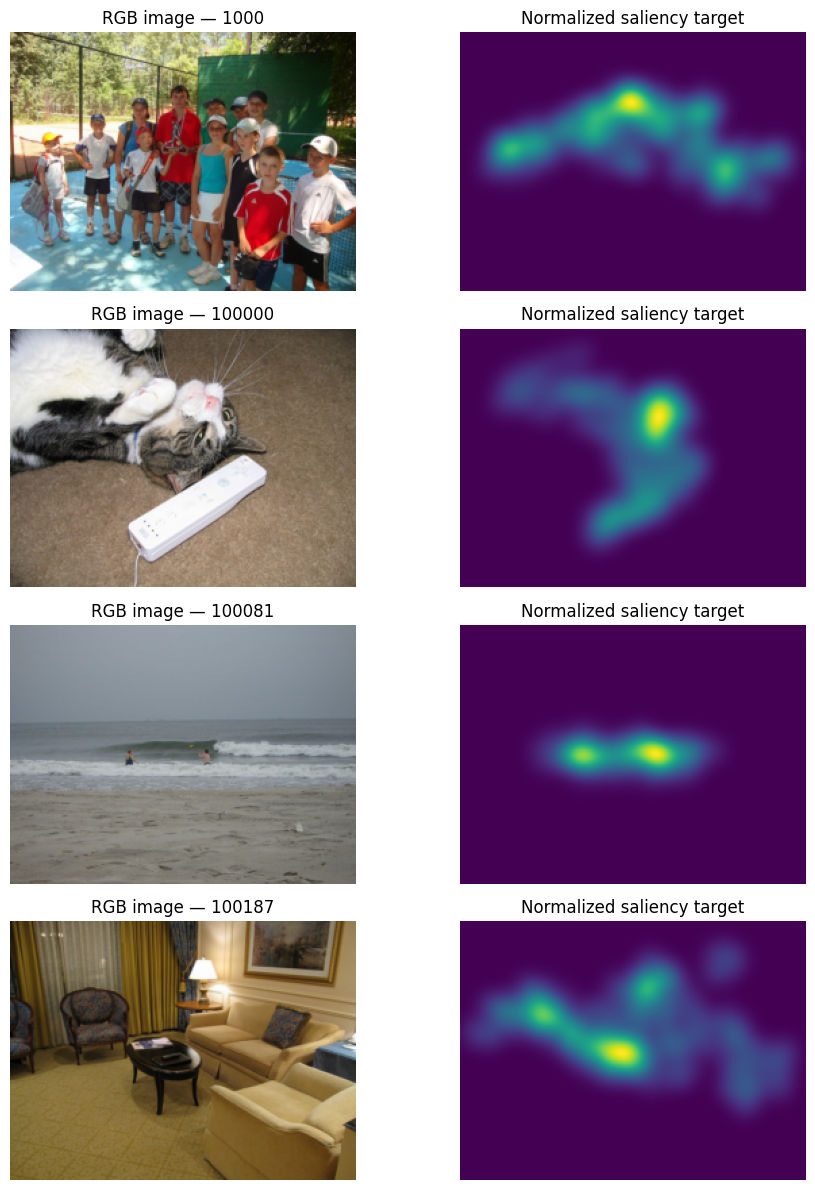

Figure saved to: /content/drive/MyDrive/saliency_project/outputs/figures/data_pipeline_examples.png


In [64]:
number_of_examples = 4

figure, axes = plt.subplots(
    number_of_examples,
    2,
    figsize=(10, 3 * number_of_examples),
    squeeze=False,
)

for row_index in range(number_of_examples):
    current_sample = val_dataset[row_index]

    display_image = denormalize_image(
        current_sample["image"]
    )

    display_target = current_sample[
        "target"
    ][0].cpu()

    axes[row_index, 0].imshow(
        display_image.permute(1, 2, 0)
    )

    axes[row_index, 0].set_title(
        f"RGB image — {current_sample['sample_id']}"
    )

    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(
        display_target
    )

    axes[row_index, 1].set_title(
        "Normalized saliency target"
    )

    axes[row_index, 1].axis("off")

figure.tight_layout()

figure_path = (
    FIGURE_ROOT
    / "data_pipeline_examples.png"
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Figure saved to:", figure_path)

## 15. Data-pipeline milestone

The PyTorch data pipeline is considered valid when:

- the GitHub repository and Drive dataset are found;
- the existing train, validation and test manifests load without modification;
- the correct manifest columns are selected;
- one sample has image shape `[3, 192, 256]`;
- one sample has target shape `[1, 192, 256]`;
- each saliency target is non-negative and sums to one;
- one batch has the expected dimensions;
- all targets in a batch sum to one;
- displayed RGB images and saliency maps remain spatially aligned.

No neural network has been trained in this notebook.

The next project stage is to implement and test the saliency losses and
evaluation metrics:

- Kullback–Leibler divergence (KLD);
- correlation coefficient (CC);
- similarity metric (SIM).

After those metrics pass their sanity tests, the non-learned MeanMap baseline
will be constructed.